# Decision Tree from Scratch — Iris Dataset

A **Decision Tree** is a model that makes predictions by asking a series of simple
yes/no questions about the input features, such as *"Is Petal Length <= 2.45?"*.
Starting from the root, each question splits the data into two branches, and this
repeats until the tree reaches a final answer at a **leaf**.

At every split, the tree tries all the features and possible thresholds, and picks
the one that best separates the classes — that is, the split that makes each
resulting group as "pure" (single-class) as possible.

The animation below shows this happening on the real Iris data: as the tree adds
splits (using Petal Length and Petal Width), the plane gets divided into regions
that increasingly match the true classes.


![Decision Tree Animation](GIF/decision_tree.gif)

## 1. Load and Explore the Data

Let's load the Iris dataset and take a first look at it.

In [7]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

df = pd.read_csv("datasets/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**About this dataset:**
- **Input features:** `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm` — all numeric measurements (in cm).
- **Target variable:** `Species` — the type of iris flower.
- **Problem type:** multi-class classification with 3 classes: `Iris-setosa`, `Iris-versicolor`, `Iris-virginica`.
- There are no missing values, and the `Id` column is just a row index, not a feature.


## 2. Select Features and Target

We drop the `Id` column (it carries no information about the flower) and separate
the input features from the target.

Decision Trees don't need feature scaling (no normalization/standardization
required): every split is just a threshold comparison like `feature <= value`,
so the scale of the features doesn't affect how the tree works.

In [8]:
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_cols].to_numpy()
y = df["Species"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (150, 4)
y shape: (150,)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## 3. Train/Test Split

We split the data into 80% training and 20% testing, with a fixed `random_state`
so results are reproducible.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 120
Test size: 30


## 4. The Math Behind Decision Trees

**Gini Impurity** measures how "mixed" a set of labels is:

$$Gini = 1 - \sum_i p_i^2$$

where $p_i$ is the proportion of samples belonging to class $i$ in the node.
- `Gini = 0` means the node is **pure** (all samples belong to one class).
- Higher Gini means the classes are more mixed together.

**Finding the best split:** for every feature and every candidate threshold, the
tree checks how much splitting the data there would reduce the impurity
(weighted by how many samples land in each branch). It picks the feature and
threshold with the **greatest impurity reduction**.

**Recursive splitting:** after the first split, the tree repeats the exact same
process independently on each branch, splitting it further, until a stopping
condition is met (max depth reached, too few samples, or the node is already pure).

**Leaf prediction:** once a branch stops splitting, that leaf simply predicts the
**majority class** among the samples that ended up there (using `Counter`).


## 5. Decision Tree From Scratch

Now let's implement the tree. We'll use a small `Node` class to represent both
internal (splitting) nodes and leaves, plus a few small functions:

- `gini(y)` — impurity of a set of labels.
- `best_split(X, y)` — best feature + threshold to split on.
- `build_tree(X, y, depth)` — recursively grows the tree.
- `predict_sample(node, x)` — walks one sample down the tree to a leaf.


In [10]:
class Node:
    """A node in the tree: either a split (has feature/threshold/children)
    or a leaf (has a predicted class)."""
    def __init__(self):
        self.feature = None      # index of the feature used to split
        self.threshold = None    # threshold value used to split
        self.left = None         # left child (feature <= threshold)
        self.right = None        # right child (feature > threshold)
        self.prediction = None   # set only for leaves (majority class)

    def is_leaf(self):
        return self.prediction is not None

In [11]:
def gini(y):
    """Gini impurity of a set of labels: 0 = pure, higher = more mixed."""
    counts = Counter(y)
    n = len(y)
    return 1 - sum((count / n) ** 2 for count in counts.values())

In [12]:
def best_split(X, y):
    """Try every feature and every possible threshold, and return the one
    that gives the lowest weighted impurity after the split."""
    n_samples, n_features = X.shape
    parent_impurity = gini(y)

    best_gain = 0.0
    best_feature, best_threshold = None, None

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])  # candidate thresholds
        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask

            # skip splits that leave one side empty
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            left_impurity = gini(y[left_mask])
            right_impurity = gini(y[right_mask])
            weighted_impurity = (
                left_mask.sum() * left_impurity + right_mask.sum() * right_impurity
            ) / n_samples

            gain = parent_impurity - weighted_impurity
            if gain > best_gain:
                best_gain = gain
                best_feature, best_threshold = feature, threshold

    return best_feature, best_threshold, best_gain

In [13]:
def build_tree(X, y, depth=0, max_depth=4, min_samples=5):
    """Recursively build the tree: stop and return a leaf if the node is
    pure, too small, or max depth is reached; otherwise split and recurse."""
    node = Node()

    # stopping conditions -> make this a leaf
    if depth >= max_depth or len(y) < min_samples or gini(y) == 0:
        node.prediction = Counter(y).most_common(1)[0][0]
        return node

    feature, threshold, gain = best_split(X, y)

    # no useful split found -> also make this a leaf
    if feature is None or gain <= 0:
        node.prediction = Counter(y).most_common(1)[0][0]
        return node

    # otherwise, split and recurse on both branches
    node.feature = feature
    node.threshold = threshold
    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    node.left = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples)
    node.right = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth, min_samples)
    return node

In [14]:
def predict_sample(node, x):
    """Walk a single sample down the tree from the root to a leaf."""
    if node.is_leaf():
        return node.prediction
    if x[node.feature] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

def predict(tree, X):
    """Predict labels for a whole dataset (array of samples)."""
    return np.array([predict_sample(tree, x) for x in X])

## 6. Training the Model

During training, `build_tree` starts with all the training data at the root, and
at every step it picks the split that best separates the classes for the data
currently in that branch. Each branch keeps splitting on its own, growing the
tree deeper, until it hits a stopping condition and becomes a leaf.

In [15]:
tree = build_tree(X_train, y_train, max_depth=4, min_samples=5)
print("Tree trained.")

Tree trained.


## 7. Making Predictions

Now we use the trained tree to predict the species for every sample in the test set.

In [16]:
y_pred = predict(tree, X_test)
y_pred[:10]  # preview first 10 predictions

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype='<U15')

## 8. Model Evaluation

We compute accuracy manually, and also build a simple 3x3 confusion matrix
(rows = true class, columns = predicted class).

In [17]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [18]:
classes = sorted(df["Species"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

confusion_matrix = np.zeros((3, 3), dtype=int)
for true_label, pred_label in zip(y_test, y_pred):
    confusion_matrix[class_to_idx[true_label], class_to_idx[pred_label]] += 1

print("Classes order:", classes)
print(confusion_matrix)

Classes order: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## 9. Visualization: Decision Regions

Since Iris has 4 features, we can't plot the full decision boundary in 2D.
Instead, we retrain a tree using only the two most informative features —
**Petal Length** and **Petal Width** — just for this plot, and show how it
divides the plane into regions, together with the real data points.

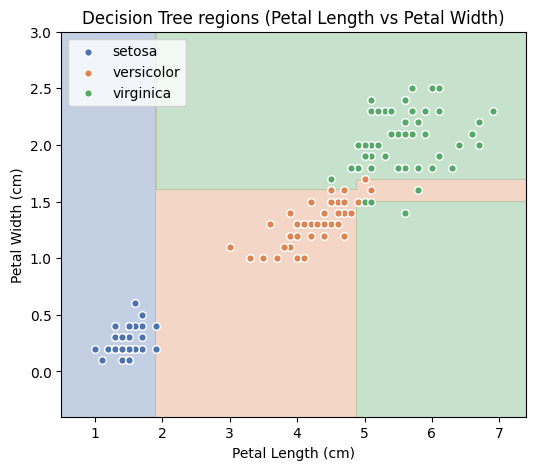

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# retrain using only 2 features, purely for visualization
X_2d = df[["PetalLengthCm", "PetalWidthCm"]].values
y_2d = df["Species"].values
tree_2d = build_tree(X_2d, y_2d, max_depth=4, min_samples=5)

colors = ["#4C72B0", "#DD8452", "#55A868"]
cmap_bg = ListedColormap([c + "55" for c in colors])
class_to_idx_2d = {c: i for i, c in enumerate(classes)}

# build a grid covering the feature range, and predict a class for every point
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = predict(tree_2d, grid_points)
grid_preds_idx = np.array([class_to_idx_2d[c] for c in grid_preds]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_preds_idx, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
for i, c in enumerate(classes):
    mask = y_2d == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[i], edgecolor="white",
                s=30, label=c.replace("Iris-", ""))
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Tree regions (Petal Length vs Petal Width)")
plt.legend()
plt.show()

## Conclusion

A **Decision Tree** predicts by asking a sequence of simple threshold questions
about the input features. At every step, it measures **impurity** (Gini) to find
the feature and threshold that best separates the classes, and picks the split
with the greatest impurity reduction.

The tree builds itself **recursively**: each branch repeats the same
split-searching process on its own subset of data, growing deeper until it hits
a stopping condition (max depth, too few samples, or a pure node).

Finally, each **leaf** makes its prediction simply by majority vote among the
training samples that ended up there. On the Iris dataset, this simple from-scratch
approach reaches high accuracy, showing how a handful of well-chosen splits is
enough to separate the three flower species.
